# Default SVM, RF, and LR

--- Model Performance Comparison ---
                                Accuracy  Sensitivity  Specificity   AUC-ROC  \
Logistic Regression (Baseline)  0.973684     0.952381     0.986111  0.996032   
Random Forest (Default)         0.973684     0.928571     1.000000  0.992890   
Random Forest (Tuned)           0.964912     0.904762     1.000000  0.994213   
SVM                             0.973684     0.928571     1.000000  0.992725   

                                False Negatives  False Positives  
Logistic Regression (Baseline)                2                1  
Random Forest (Default)                       3                0  
Random Forest (Tuned)                         4                0  
SVM                                           3                0  


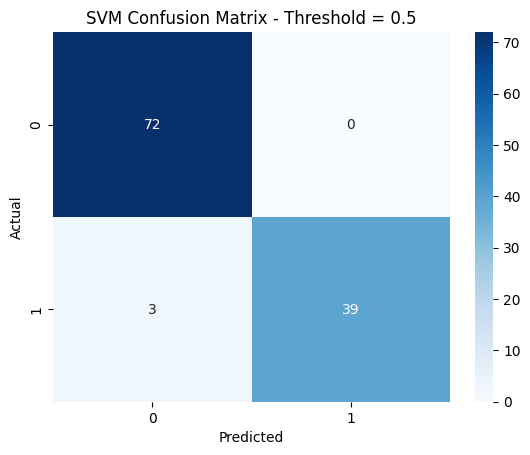

In [9]:
# Importing the relevant tools used to create the SVM, RF, and diagrams
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, recall_score, 
                             roc_auc_score, classification_report, ConfusionMatrixDisplay)
import zipfile

# Loading the data by unzipping the file
zip_path = "/Users/seanrampersad/downloads/breast_cancer_wisconsin_diagnostic.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".data") or file.endswith(".csv"):
            data_file = os.path.join(root, file)

# Defining columns manually as the raw WDBC data files lack a header row
columns = [
    "id","diagnosis",
    "radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean",
    "radius_se","texture_se","perimeter_se","area_se","smoothness_se",
    "compactness_se","concavity_se","concave_points_se","symmetry_se","fractal_dimension_se",
    "radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
    "compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]

# Loading the data into a pandas DataFrame
df = pd.read_csv(data_file, header=None, names=columns)

# Converting categorical 'diagnosis' (M/B) into numeric values (1/0) for the model
label_e = LabelEncoder()
df['diagnosis'] = label_e.fit_transform(df['diagnosis'])

# Separate features (X) from the target label (y) and drop the unique 'id' column
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# Split the data into Training (80%) and Testing (20%) sets
# The 'stratify' function ensures the proportion of Malignant/Benign cases is consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Standardizing features for model to learn from
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the primary models using optimized parameters
best_estimators = {
    'Logistic Regression': LogisticRegression(C=1, solver='liblinear', random_state=42).fit(X_train_scaled, y_train),
    'Random Forest': RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42).fit(X_train_scaled, y_train),
    'SVM': SVC(C=10, kernel='rbf', probability=True, random_state=42).fit(X_train_scaled, y_train)
}

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    
    # Calculating key metrics to compare between models
    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred) 
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y, y_proba)
    
    return [accuracy, sensitivity, specificity, auc_roc, fn, fp]
log_reg = best_estimators['Logistic Regression']


rf_default = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)

rf_tuned = best_estimators['Random Forest']

svm_model = best_estimators['SVM']

data = {
    "Logistic Regression (Baseline)": evaluate_model(log_reg, X_test_scaled, y_test),
    "Random Forest (Default)": evaluate_model(rf_default, X_test_scaled, y_test),
    "Random Forest (Tuned)": evaluate_model(rf_tuned, X_test_scaled, y_test),
    "SVM": evaluate_model(svm_model, X_test_scaled, y_test)
}
# Convert results into a formatted DataFrame for easy comparison
results_df = pd.DataFrame.from_dict(data, orient='index', 
                                    columns=['Accuracy', 'Sensitivity', 'Specificity', 'AUC-ROC', 'False Negatives', 'False Positives'])

fmt = {'Accuracy': '{:.2%}', 'Sensitivity': '{:.2%}', 'Specificity': '{:.2%}', 'AUC-ROC': '{:.4f}', 'False Negatives': '{:0.0f}', 'False Positives': '{:0.0f}'}
print("--- Model Performance Comparison ---")
print(results_df.style.format(fmt))
print(results_df) 

best_model = best_estimators['SVM']
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]


sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix - Threshold = 0.5')
plt.show()

# SVM Tuning

   Threshold  Accuracy  Sensitivity  Specificity   AUC-ROC  FN  FP
0        0.5  0.973684     0.928571     1.000000  0.992725   3   0
1        0.4  0.973684     0.952381     0.986111  0.992725   2   1
2        0.3  0.964912     0.952381     0.972222  0.992725   2   2
3        0.2  0.947368     0.976190     0.930556  0.992725   1   5


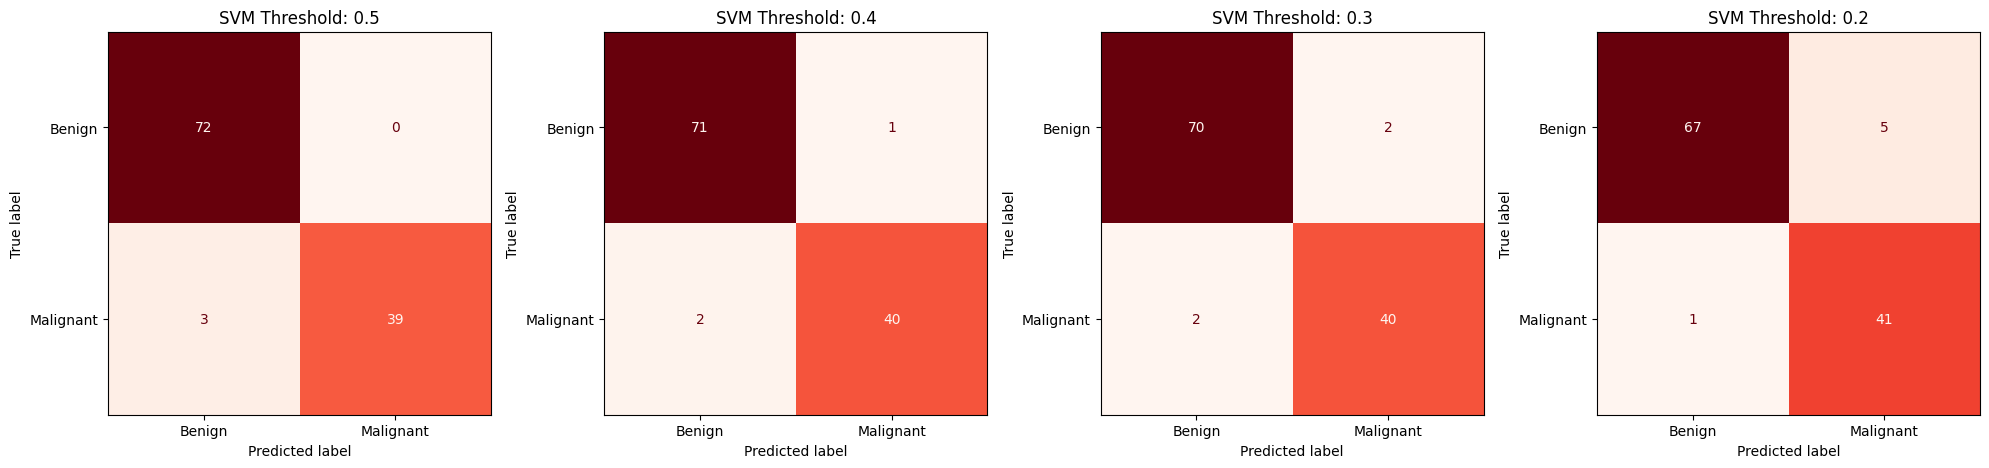

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [18]:
# Initializing and fitting the SVM model
svm_advanced = SVC(C=10, kernel='rbf', probability=True, random_state=42)
svm_advanced.fit(X_train_scaled, y_train)

# Defining clinical thresholds for analysis
thresholds = [0.5, 0.4, 0.3, 0.2]
y_probs = svm_advanced.predict_proba(X_test_scaled)[:, 1]

# Setting up the subplots for confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
results = []


for i, t in enumerate(thresholds):
    # Calculating binary predictions based on the current threshold
    y_pred_t = (y_probs >= t).astype(int)
    
    # Extracting the confusion Matrix components
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculating the clinical metrics
    accuracy = accuracy_score(y_test, y_pred_t)
    sensitivity = recall_score(y_test, y_pred_t)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_roc = roc_auc_score(y_test, y_probs)
    
    # Storing the results for the performance table
    results.append({
        "Threshold": t,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC-ROC": auc_roc,
        "FN": fn,
        "FP": fp
    })
    
    # Generating the plot 
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred_t, 
        ax=axes[i], 
        cmap='Reds',
        colorbar=False,
        display_labels=["Benign", "Malignant"]
    )
    axes[i].set_title(f"SVM Threshold: {t}")

# Displaying the performance table
results_df = pd.DataFrame(results)
print(results_df)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))



# Graphing Specificity and Sensitivity of SVM with Different Thresholds

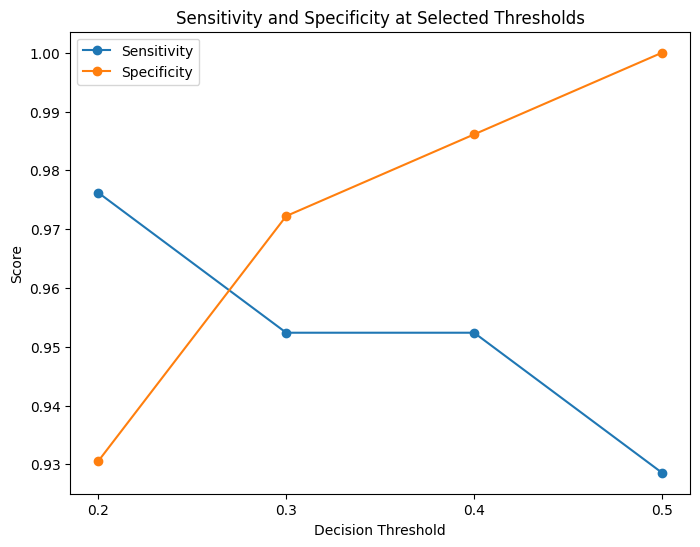

In [26]:
sensitivities = []
specificities = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    sensitivities.append(sensitivity)
    specificities.append(specificity)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, sensitivities, marker='o', label="Sensitivity")
plt.plot(thresholds, specificities, marker='o', label="Specificity")

# Force x-axis to show only these thresholds
plt.xticks(thresholds)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Sensitivity and Specificity at Selected Thresholds")
plt.legend()
plt.show()

# Random Forest Tuning

 Threshold  Accuracy  Sensitivity  Specificity  AUC-ROC  Missed Cancers (FN)  Unnecessary Biopsies (FP)
       0.5  0.973684     0.928571     1.000000  0.99289                    3                          0
       0.4  0.964912     0.928571     0.986111  0.99289                    3                          1
       0.3  0.947368     0.928571     0.958333  0.99289                    3                          3
       0.2  0.929825     0.952381     0.916667  0.99289                    2                          6


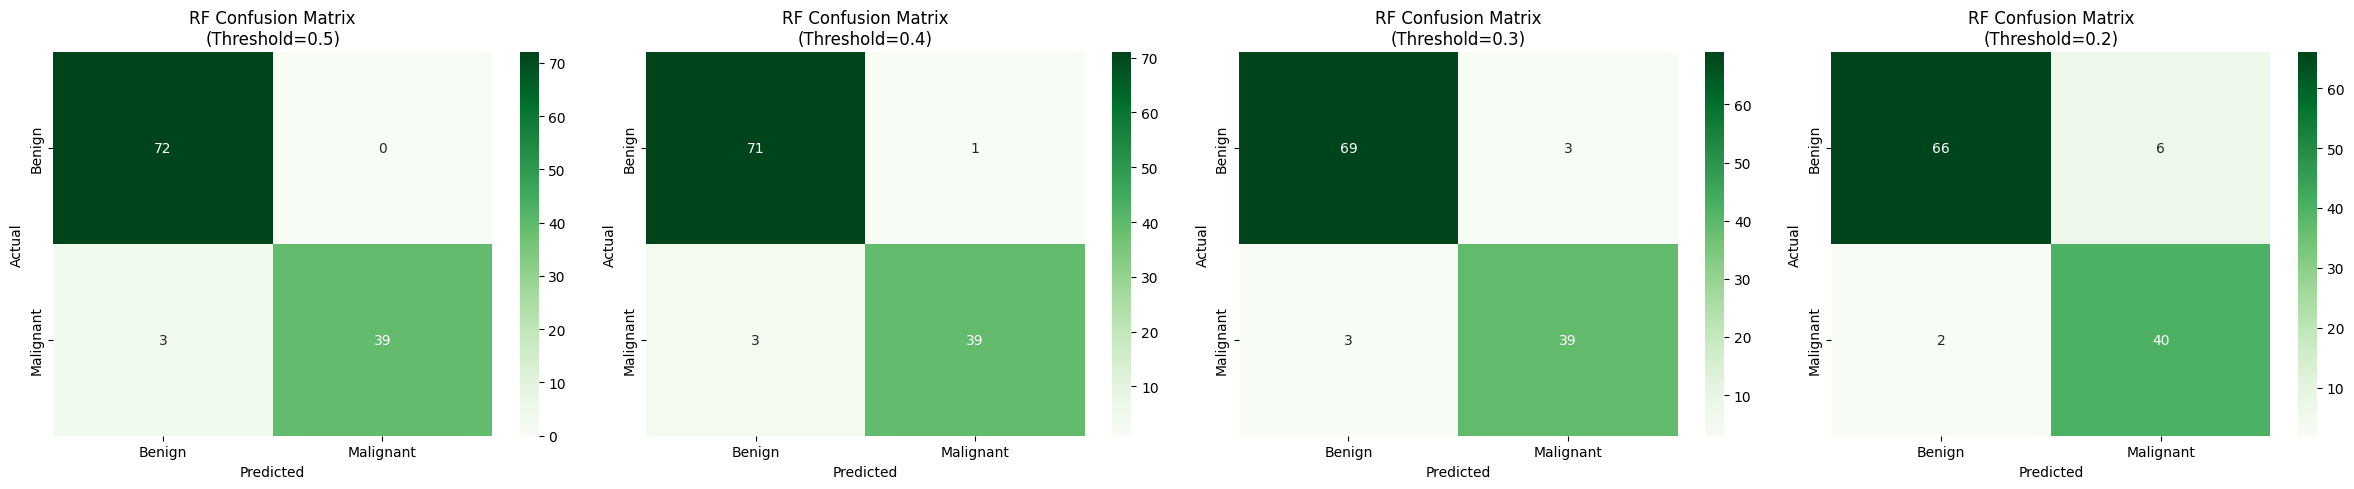

In [ ]:

# Tuning the default RF model
rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, random_state=42)
rf_tuned.fit(X_train, y_train)

rf_probs = rf_tuned.predict_proba(X_test)[:, 1]

# Defining clinical thresholds for analysis
rf_thresholds = [0.5, 0.4, 0.3, 0.2]

results = []
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, t in enumerate(rf_thresholds):
    preds = (rf_probs >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_test, preds)
    sensitivity = recall_score(y_test, preds)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_roc = roc_auc_score(y_test, rf_probs)
    
    results.append({
        "Threshold": t,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC-ROC": auc_roc,
        "Missed Cancers (FN)": fn,
        "Unnecessary Biopsies (FP)": fp
    })
    
    # Plotting confusion matrices
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    axes[i].set_title(f'RF Confusion Matrix\n(Threshold={t})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('rf_thresholds_performance.png')

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv('rf_threshold_results.csv', index=False)

# Graphing Specificity and Sensitivity of RF with Different Thresholds

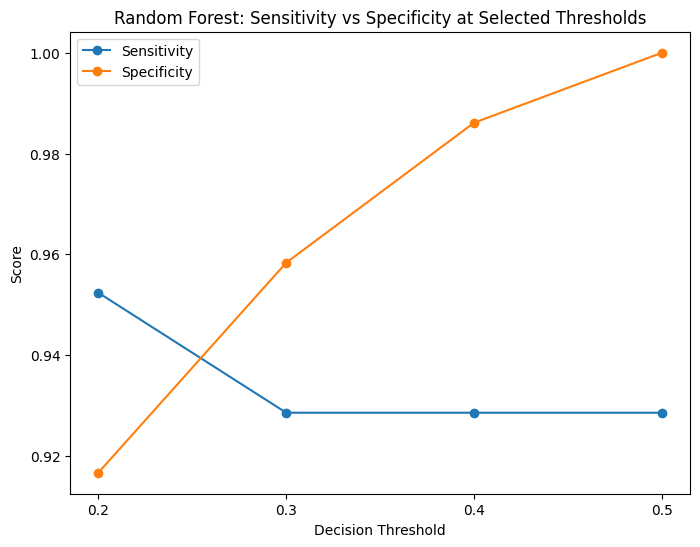

In [29]:
sensitivities = []
specificities = []

for t in rf_thresholds:
    preds = (rf_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    sensitivities.append(sensitivity)
    specificities.append(specificity)

# Plot Sensitivity and Specificity together
plt.figure(figsize=(8, 6))
plt.plot(rf_thresholds, sensitivities, marker='o', label='Sensitivity')
plt.plot(rf_thresholds, specificities, marker='o', label='Specificity')

plt.xticks(rf_thresholds)  # Force x-axis to show only these thresholds
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Random Forest: Sensitivity vs Specificity at Selected Thresholds")
plt.legend()
plt.show()

# Description of Findings

Using Support Vector Machines (SVM) allows for a sophisticated data driven approach that can supplement decision making in distinguishing between malignant and benign cells. SVM provides an advantage over Linear Regression (LR) and Random Forest (RF) given the binary classification of the task, multicollinearity, limited amount of data, and outliers within the database. In comparison to LR, SVM showed a sensitivity of 1.0, which is a quality of an algorithm that would be prioritized as it’s important in assuring that malignant cases are detected. A threshold of 0.4 for our SVM showed superior results in comparison to any tuning to the RF model given that it produced the fewest number of false negatives while having a 96% recall value and a 97% accuracy. In oncology, early detection is key to increasing survival rates of patients, as the disease is easier to manager and can allow for less aggressive treatment options (Bartlett et al., 2021). From a medical diagnostic perspective, it’s often viewed optimal to minimize the false negative rate as missed cancers can result in progression, delayed treatment, and potential mortality (Bartlett et al., 2021). 

1.	Bartlett, E. C., Silva, M., Callister, M. E., & Devaraj, A. (2021). False-negative results in lung cancer screening—Evidence and controversies. Clinical Imaging. Advance online publication.
